In [3]:
import pandas as pd

In [2]:
df = pd.read_parquet("~/Downloads/flight_list_202303.parquet")
df

,id,icao24,flt_id,dof,adep,ades,adep_p,ades_p,registration,model,typecode,icao_aircraft_class,icao_operator,first_seen,last_seen,version,unix_time
0,9708855407662,4cac79,SAS40G,2023-03-05,ESSA,EKCH,,,EI-SIJ,NaN,A20N,L2J,NaN,2023-03-05 21:02:15,2023-03-05 21:56:50,v2.0.0,1678050135
1,12032730349952,478791,WIF13F,2023-03-17,NaN,ENGM,,,LN-WSC,DHC-8 202,DH8B,L2T,WIF,2023-03-17 17:38:10,2023-03-17 18:22:20,v2.0.0,1679074690
2,12729728856255,4bb855,PGT6CF,2023-03-30,NaN,LTFJ,,,TC-NBU,NaN,A20N,L2J,NaN,2023-03-30 20:11:40,2023-03-30 20:49:10,v2.0.0,1680207100
3,49052664614223,478f5c,SAS943,2023-03-30,NaN,NaN,NaN,NaN,LN-RKM,A330 343X,A333,L2J,SAS,2023-03-30 16:49:50,2023-03-30 16:59:55,v2.0.0,1680194990
4,116288504147708,478387,SAS88R,2023-03-15,ENGM,ESSA,,,LN-RKI,A321 232,A321,L2J,SAS,2023-03-15 10:23:55,2023-03-15 11:05:55,v2.0.0,1678875835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127481,18446686492734726923,347247,IBS3881,2023-03-13,NaN,LEMD,,,EC-NST,NaN,A21N,L2J,NaN,2023-03-13 21:50:35,2023-03-13 22:36:45,v2.0.0,1678744235
1127482,18446691637655451427,4bb288,THY8KT,2023-03-28,ENGM,LTFM,,,TC-LTH,NaN,A21N,L2J,NaN,2023-03-28 10:30:45,2023-03-28 13:52:00,v2.0.0,1679999445
1127483,18446719608351614154,4ca568,RYR46SN,2023-03-31,EIDW,EHAM,,,EI-DWC,BOEING 737-8AS,B738,L2J,RYR,2023-03-31 14:48:40,2023-03-31 15:56:50,v2.0.0,1680274120
1127484,18446737205811019352,4406de,AUA15,2023-03-14,LOWW,NaN,,,OE-LPE,777 2Q8ER,B772,L2J,AUA,2023-03-14 19:30:50,2023-03-14 21:18:20,v2.0.0,1678822250


# Follow up on reasoning behind Fig 4

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [5]:
# Evaluation results, EGWP 100
dff = pd.read_parquet("../data/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)

dfo = pd.read_parquet("../data/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)

In [16]:
df = dff.groupby("flight_id").agg({"fl_diff": "min", "day": "first"}) #.groupby("day")#.plot.hist()

<Axes: xlabel='day'>

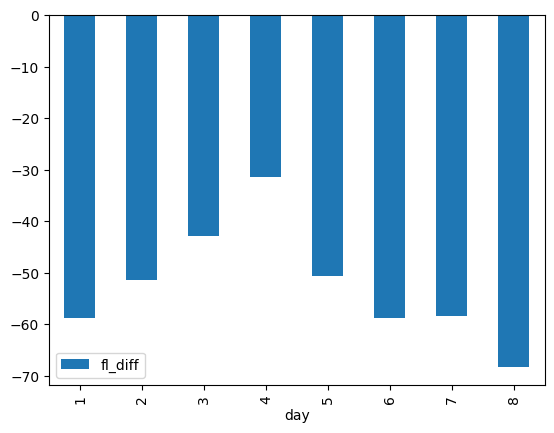

In [25]:
df.groupby("day").mean().plot.bar()

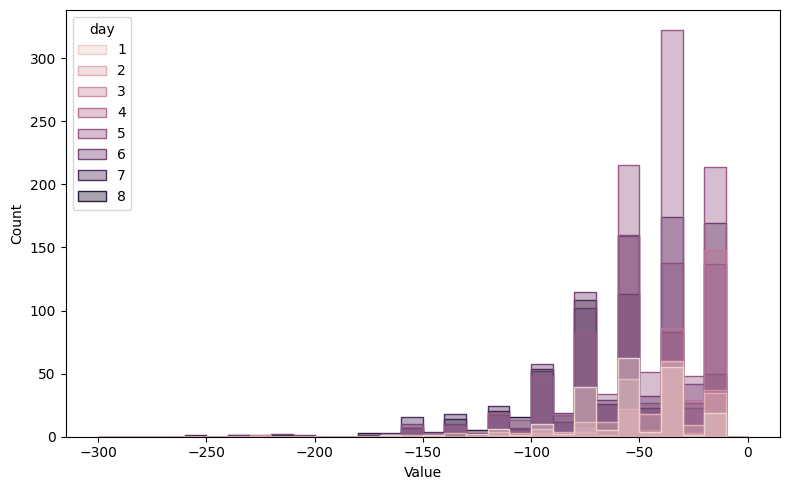

In [22]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

bins = np.arange(-300, 10, 10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='fl_diff', hue='day', bins=bins, alpha=0.4, element='step', ax=ax)
ax.set_xlabel('Value')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Forecast uncertainty

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [34]:
# Evaluation results, EGWP 100
dff = pd.read_parquet("../data/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)

dfo = pd.read_parquet("../data/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)

In [35]:
dff["CO2_CoCiP"] = dff["CO2"] + dff["CoCiP"]
dfo["CO2_CoCiP"] = dfo["CO2"] + dfo["CoCiP"]

dff["NOx_H2O"] = dff["NOx"] + dff["H2O"]
dfo["NOx_H2O"] = dfo["NOx"] + dfo["H2O"]

dff["Total"] = dff["CO2"] + dff["CoCiP"] + dff["NOx"] + dff["H2O"]
dfo["Total"] = dfo["CO2"] + dfo["CoCiP"] + dfo["NOx"] + dfo["H2O"]

In [36]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby(["flight_id"]).sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby(["flight_id"]).sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

In [46]:
# Methodology and also Discussion (July 3, 2026)
print(my_diff.query("CoCiP_filed < CoCiP_optimised").shape[0] / 4112 * 100)
print(my_diff.query("CO2_CoCiP_filed < CO2_CoCiP_optimised").shape[0] / 4112 * 100)

print(my_diff.query("CoCiP_filed > CoCiP_optimised").shape[0] / 4112 * 100)
print(my_diff.query("CO2_CoCiP_filed > CO2_CoCiP_optimised").shape[0] / 4112 * 100)

# n flights
print(my_diff.query("CoCiP_filed == CoCiP_optimised").shape[0])
print(my_diff.query("CO2_CoCiP_filed == CO2_CoCiP_optimised").shape[0])

10.821984435797665
14.810311284046692
88.18093385214007
85.18968871595331
41
0


In [ ]:
dff.groupby("flight_id").contrail_age

,waypoint,flight_id,typecode,timestamp,time,latitude,longitude,fl,altitude_ft,pressure,...,CO2_with_aCCF,CO2,day,fir,fl_diff,deviation,is_excluded,CO2_CoCiP,NOx_H2O,Total
0,1,702,A333,2023-09-02 19:45:00,2023-09-02 19:45:00,51.464792,-0.482314,1,100.0,1009.591776,...,300.691880,835.698843,4,EGTT,0,False,False,835.698843,0.000000,835.698843
1,2,702,A333,2023-09-02 19:46:00,2023-09-02 19:46:00,51.451971,-0.420505,21,2100.0,938.643083,...,311.486938,865.701041,4,EGTT,0,False,False,865.701041,3764.634965,4630.336007
2,3,702,A333,2023-09-02 19:47:00,2023-09-02 19:47:00,51.431902,-0.361463,41,4100.0,871.786772,...,290.112734,806.296717,4,EGTT,0,False,False,806.296717,3007.084452,3813.381169
3,4,702,A333,2023-09-02 19:48:00,2023-09-02 19:48:00,51.372274,-0.390776,62,6200.0,805.791820,...,280.931198,780.778906,4,EGTT,0,False,False,780.778906,2812.803430,3593.582336
4,5,702,A333,2023-09-02 19:49:00,2023-09-02 19:49:00,51.306960,-0.444349,88,8800.0,729.749172,...,274.712188,763.494702,4,EGTT,0,False,False,763.494702,2447.496906,3210.991608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370982,394,2813,A333,2023-12-21 09:48:00,2023-12-21 09:48:00,40.200219,-3.470401,54,5400.0,830.437744,...,23.325496,64.827456,7,NaN,0,False,False,64.827456,35.246858,100.074314
1370983,395,2813,A333,2023-12-21 09:49:00,2023-12-21 09:49:00,40.261213,-3.489742,45,4500.0,858.890382,...,23.522003,65.373601,7,NaN,0,False,False,65.373601,36.629757,102.003358
1370984,396,2813,A333,2023-12-21 09:50:00,2023-12-21 09:50:00,40.319544,-3.508239,35,3500.0,891.424971,...,23.740346,65.980429,7,NaN,0,False,False,65.980429,38.657435,104.637864
1370985,397,2813,A333,2023-12-21 09:51:00,2023-12-21 09:51:00,40.373377,-3.525271,31,3100.0,904.714958,...,42.492701,118.097970,7,NaN,0,False,False,118.097970,70.149139,188.247109


In [69]:
dff["contrail_age_h"] = dff.contrail_age.dt.total_seconds() / 3600
dff.query("contrail_age_h < 7").shape[0] / dff.shape[0]
dff.query("contrail_age_h >= 7").shape[0] / dff.shape[0]

0.025095788654451136

In [66]:
(dff.contrail_age.dt.total_seconds() / 3600)#.plot.hist()

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1370982    0.0
1370983    0.0
1370984    0.0
1370985    0.0
1370986    0.0
Name: contrail_age, Length: 1370987, dtype: float64

<Axes: ylabel='Frequency'>

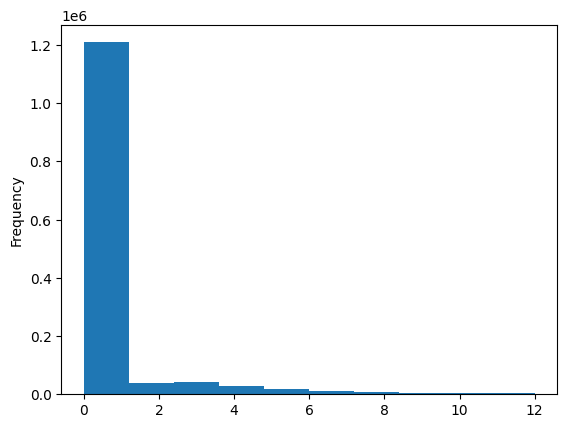

In [60]:
(dfo.contrail_age.dt.total_seconds() / 3600).plot.hist()

1.1043396879548946 1.1154158927301243


<Axes: ylabel='Frequency'>

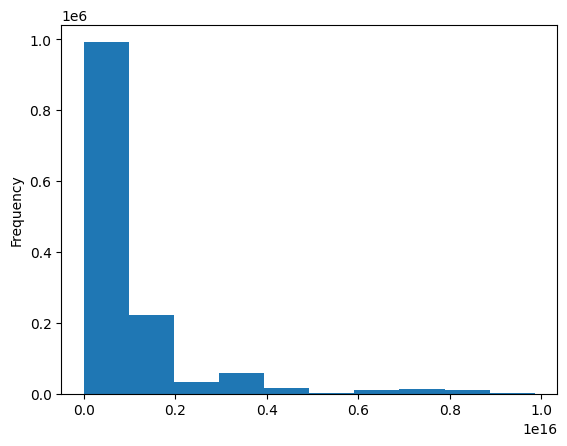

In [73]:
print(dff.nvpm_ei_n.mean() / 1e15, dfo.nvpm_ei_n.mean() / 1e15)
dff.nvpm_ei_n.plot.hist()

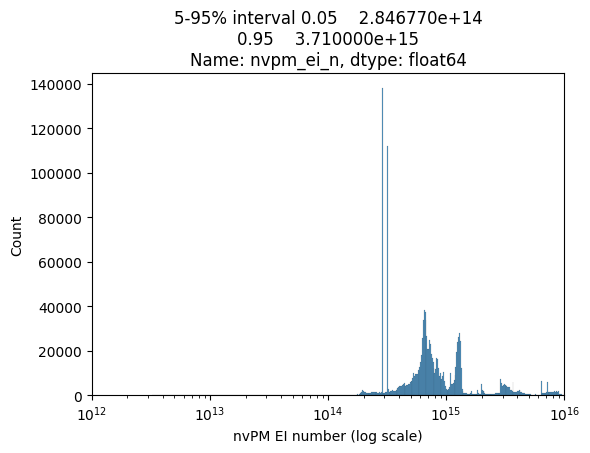

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(data=dff, x='nvpm_ei_n', log_scale=True, ax=ax)
ax.set_xlabel('nvPM EI number (log scale)')
ax.set_ylabel('Count')
ax.set_xlim([1e12, 1e16])
plt.tight_layout()

plt.title(f"5-95% interval {dff.nvpm_ei_n.quantile([0.05, 0.95])}")
plt.show()

In [ ]:
print(dff.nvpm_ei_n.quantile([0.005, 0.995]).values, dfo.nvpm_ei_n.quantile([0.005, 0.995]).values)
# 2.8e14, 3.7e15 and 2.8e14, 3.7e15 5th-95th
#

[1.97190221e+14 8.59815934e+15] [1.97076387e+14 8.62630963e+15]
